# Import necessary libraries


In [60]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# 1: Load the dataset


In [61]:
url = "https://raw.githubusercontent.com/SR1608/Datasets/main/covid-data.csv"
df = pd.read_csv(url)

# 2: High Level Data Understanding


# a. Find no. of rows & columns in the dataset

In [62]:
print("Rows and Columns:", df.shape)


Rows and Columns: (57394, 49)


# b. Data types of columns. 

In [63]:
print("\nData Types:\n", df.dtypes)


Data Types:
 iso_code                               object
continent                              object
location                               object
date                                   object
total_cases                           float64
new_cases                             float64
new_cases_smoothed                    float64
total_deaths                          float64
new_deaths                            float64
new_deaths_smoothed                   float64
total_cases_per_million               float64
new_cases_per_million                 float64
new_cases_smoothed_per_million        float64
total_deaths_per_million              float64
new_deaths_per_million                float64
new_deaths_smoothed_per_million       float64
reproduction_rate                     float64
icu_patients                          float64
icu_patients_per_million              float64
hosp_patients                         float64
hosp_patients_per_million             float64
weekly_icu_admission

# c. Info & describe of data in dataframe. 

In [64]:
print("\nData Info:\n")
df.info()
print("\nData Description:\n", df.describe())



Data Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57394 entries, 0 to 57393
Data columns (total 49 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   iso_code                            57071 non-null  object 
 1   continent                           56748 non-null  object 
 2   location                            57394 non-null  object 
 3   date                                57394 non-null  object 
 4   total_cases                         53758 non-null  float64
 5   new_cases                           56465 non-null  float64
 6   new_cases_smoothed                  55652 non-null  float64
 7   total_deaths                        44368 non-null  float64
 8   new_deaths                          56465 non-null  float64
 9   new_deaths_smoothed                 55652 non-null  float64
 10  total_cases_per_million             53471 non-null  float64
 11  new_cases_per_million       

# 3. Low Level Data Understanding : 

# a. Find count of unique values in location column. 


In [65]:
print("\nUnique locations count:", df['location'].nunique())



Unique locations count: 216


# b. Find which continent has maximum frequency using values counts. 

In [66]:
print("\nContinent with max frequency:\n", df['continent'].value_counts().idxmax())



Continent with max frequency:
 Europe


#   c. Find maximum & mean value in 'total_cases'.

In [67]:
print("\nMax and Mean of total_cases:\n", df['total_cases'].max(), df['total_cases'].mean())



Max and Mean of total_cases:
 55154651.0 167797.3688753302


# d. Find 25%,50% & 75% quartile value in 'total_deaths'.

In [68]:
print("\nQuartiles of total_deaths:\n", df['total_deaths'].quantile([0.25, 0.5, 0.75]))



Quartiles of total_deaths:
 0.25     13.0
0.50     84.0
0.75    727.0
Name: total_deaths, dtype: float64


# e. Find which continent has maximum 'human_development_index'.

In [69]:
print("\nContinent with max human_development_index:\n", df.loc[df['human_development_index'].idxmax(), 'continent'])



Continent with max human_development_index:
 Europe


#  f. Find which continent has minimum 'gdp_per_capita'.

In [70]:
print("\nContinent with min gdp_per_capita:\n", df.loc[df['gdp_per_capita'].idxmin(), 'continent'])



Continent with min gdp_per_capita:
 Africa


# 4. Filter the dataframe with only this columns ['continent','location','date','total_cases','total_deaths','gdp_per_ca pita',' human_development_index'] and update the data frame.

In [71]:
df = df[['continent', 'location', 'date', 'total_cases', 'total_deaths', 'gdp_per_capita', 'human_development_index']]
df

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index
0,Asia,Afghanistan,31/12/19,NaN,NaN,1803.987,0.498
1,Asia,Afghanistan,01/01/20,NaN,NaN,1803.987,0.498
2,Asia,Afghanistan,02/01/20,NaN,NaN,1803.987,0.498
3,Asia,Afghanistan,03/01/20,NaN,NaN,1803.987,0.498
4,Asia,Afghanistan,04/01/20,NaN,NaN,1803.987,0.498
...,...,...,...,...,...,...,...
57389,NaN,International,13/11/20,696.0,7.0,NaN,NaN
57390,NaN,International,14/11/20,696.0,7.0,NaN,NaN
57391,NaN,International,15/11/20,696.0,7.0,NaN,NaN
57392,NaN,International,16/11/20,696.0,7.0,NaN,NaN


# 5. Data Cleaning

# a. Remove all duplicates observations

In [72]:
df.duplicated().sum()

0

In [73]:
df.drop_duplicates()

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index
0,Asia,Afghanistan,31/12/19,NaN,NaN,1803.987,0.498
1,Asia,Afghanistan,01/01/20,NaN,NaN,1803.987,0.498
2,Asia,Afghanistan,02/01/20,NaN,NaN,1803.987,0.498
3,Asia,Afghanistan,03/01/20,NaN,NaN,1803.987,0.498
4,Asia,Afghanistan,04/01/20,NaN,NaN,1803.987,0.498
...,...,...,...,...,...,...,...
57389,NaN,International,13/11/20,696.0,7.0,NaN,NaN
57390,NaN,International,14/11/20,696.0,7.0,NaN,NaN
57391,NaN,International,15/11/20,696.0,7.0,NaN,NaN
57392,NaN,International,16/11/20,696.0,7.0,NaN,NaN


# b. Find missing values in all columns 

In [74]:
df.isnull().sum()

continent                    646
location                       0
date                           0
total_cases                 3636
total_deaths               13026
gdp_per_capita              7027
human_development_index     8147
dtype: int64

#  c. Remove all observations where continent column value is missing 

In [75]:
df.dropna(subset=["continent"])

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index
0,Asia,Afghanistan,31/12/19,NaN,NaN,1803.987,0.498
1,Asia,Afghanistan,01/01/20,NaN,NaN,1803.987,0.498
2,Asia,Afghanistan,02/01/20,NaN,NaN,1803.987,0.498
3,Asia,Afghanistan,03/01/20,NaN,NaN,1803.987,0.498
4,Asia,Afghanistan,04/01/20,NaN,NaN,1803.987,0.498
...,...,...,...,...,...,...,...
56743,Africa,Zimbabwe,13/11/20,8696.0,255.0,1899.775,0.535
56744,Africa,Zimbabwe,14/11/20,8765.0,257.0,1899.775,0.535
56745,Africa,Zimbabwe,15/11/20,8786.0,257.0,1899.775,0.535
56746,Africa,Zimbabwe,16/11/20,8786.0,257.0,1899.775,0.535


# d. Fill all missing values with 0 

In [76]:
df= df.fillna(0)

In [77]:
df.isnull().sum()

continent                  0
location                   0
date                       0
total_cases                0
total_deaths               0
gdp_per_capita             0
human_development_index    0
dtype: int64

# 6. Date time format : 

# a. Convert date column in datetime format using pandas.to_datetime 

In [93]:
df['date'] = pd.to_datetime(df['date'])

In [79]:
df.dtypes

continent                          object
location                           object
date                       datetime64[ns]
total_cases                       float64
total_deaths                      float64
gdp_per_capita                    float64
human_development_index           float64
dtype: object

# b. Create new column month after extracting month data from date column.

In [80]:
df['month'] = pd.DatetimeIndex(df['date']).month

In [81]:
df

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index,month
0,Asia,Afghanistan,2019-12-31,0.0,0.0,1803.987,0.498,12
1,Asia,Afghanistan,2020-01-01,0.0,0.0,1803.987,0.498,1
2,Asia,Afghanistan,2020-02-01,0.0,0.0,1803.987,0.498,2
3,Asia,Afghanistan,2020-03-01,0.0,0.0,1803.987,0.498,3
4,Asia,Afghanistan,2020-04-01,0.0,0.0,1803.987,0.498,4
...,...,...,...,...,...,...,...,...
57389,0,International,2020-11-13,696.0,7.0,0.000,0.000,11
57390,0,International,2020-11-14,696.0,7.0,0.000,0.000,11
57391,0,International,2020-11-15,696.0,7.0,0.000,0.000,11
57392,0,International,2020-11-16,696.0,7.0,0.000,0.000,11


# 7. Data Aggregation: 

#  a. Find max value in all columns using groupby function on 'continent' column

In [82]:
df_groupby=df.groupby('continent').max().reset_index()
df_groupby

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index,month
0,0,World,2020-12-11,55154651.0,1328537.0,15469.207,0.000,12
1,Africa,Zimbabwe,2020-12-11,752269.0,20314.0,26382.287,0.797,12
2,Asia,Yemen,2020-12-11,8874290.0,130519.0,116935.600,0.933,12
3,Europe,Vatican,2020-12-11,1991233.0,52147.0,94277.965,0.953,12
4,North America,United States Virgin Islands,2020-12-11,11205486.0,247220.0,54225.446,0.926,12
5,Oceania,Wallis and Futuna,2020-12-11,27750.0,907.0,44648.710,0.939,12
6,South America,Venezuela,2020-12-11,5876464.0,166014.0,22767.037,0.843,12


# b. Store the result in a new dataframe named 'df_groupby'. (Use df_groupby dataframe for all further analysis)

In [83]:
df.groupby('continent').max().reset_index()

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index,month
0,0,World,2020-12-11,55154651.0,1328537.0,15469.207,0.000,12
1,Africa,Zimbabwe,2020-12-11,752269.0,20314.0,26382.287,0.797,12
2,Asia,Yemen,2020-12-11,8874290.0,130519.0,116935.600,0.933,12
3,Europe,Vatican,2020-12-11,1991233.0,52147.0,94277.965,0.953,12
4,North America,United States Virgin Islands,2020-12-11,11205486.0,247220.0,54225.446,0.926,12
5,Oceania,Wallis and Futuna,2020-12-11,27750.0,907.0,44648.710,0.939,12
6,South America,Venezuela,2020-12-11,5876464.0,166014.0,22767.037,0.843,12


In [84]:
df_groupby = df.groupby('continent').max().reset_index()
df_groupby

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index,month
0,0,World,2020-12-11,55154651.0,1328537.0,15469.207,0.000,12
1,Africa,Zimbabwe,2020-12-11,752269.0,20314.0,26382.287,0.797,12
2,Asia,Yemen,2020-12-11,8874290.0,130519.0,116935.600,0.933,12
3,Europe,Vatican,2020-12-11,1991233.0,52147.0,94277.965,0.953,12
4,North America,United States Virgin Islands,2020-12-11,11205486.0,247220.0,54225.446,0.926,12
5,Oceania,Wallis and Futuna,2020-12-11,27750.0,907.0,44648.710,0.939,12
6,South America,Venezuela,2020-12-11,5876464.0,166014.0,22767.037,0.843,12


# 8. Feature Engineering :

# a. Create a new feature 'total_deaths_to_total_cases' by ratio of 'total_deaths' column to 'total_cases'

In [85]:
df_groupby['total_deaths_to_total_cases'] = df_groupby['total_deaths'] / df_groupby['total_cases']

In [86]:
df_groupby["total_deaths_to_total_cases"]*100

0    2.408749
1    2.700364
2    1.470754
3    2.618830
4    2.206241
5    3.268468
6    2.825066
Name: total_deaths_to_total_cases, dtype: float64

In [87]:
df_groupby

,continent,location,date,total_cases,total_deaths,gdp_per_capita,human_development_index,month,total_deaths_to_total_cases
0,0,World,2020-12-11,55154651.0,1328537.0,15469.207,0.000,12,0.024087
1,Africa,Zimbabwe,2020-12-11,752269.0,20314.0,26382.287,0.797,12,0.027004
2,Asia,Yemen,2020-12-11,8874290.0,130519.0,116935.600,0.933,12,0.014708
3,Europe,Vatican,2020-12-11,1991233.0,52147.0,94277.965,0.953,12,0.026188
4,North America,United States Virgin Islands,2020-12-11,11205486.0,247220.0,54225.446,0.926,12,0.022062
5,Oceania,Wallis and Futuna,2020-12-11,27750.0,907.0,44648.710,0.939,12,0.032685
6,South America,Venezuela,2020-12-11,5876464.0,166014.0,22767.037,0.843,12,0.028251


# 9. Data Visualization : 

#   a. Perform Univariate analysis on 'gdp_per_capita' column by plotting histogram using seaborn dist plot.

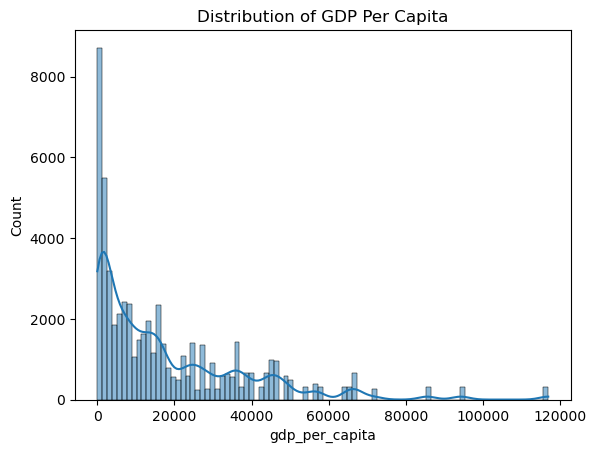

In [88]:
sns.histplot(df['gdp_per_capita'], kde=True)
plt.title("Distribution of GDP Per Capita")
plt.show()

# b. Plot a scatter plot of 'total_cases' & 'gdp_per_capita'

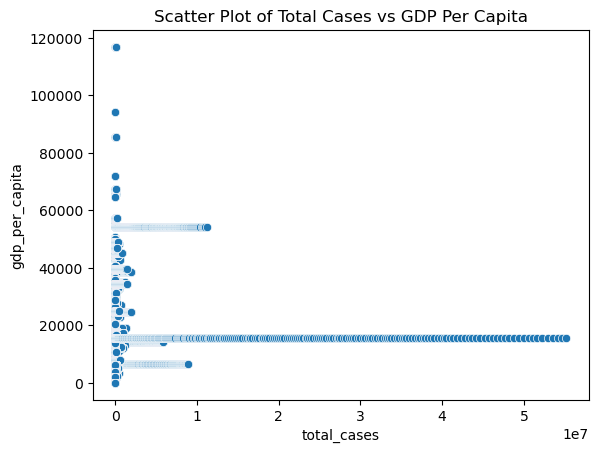

In [89]:
sns.scatterplot(x=df['total_cases'], y=df['gdp_per_capita'])
plt.title("Scatter Plot of Total Cases vs GDP Per Capita")
plt.show()

# c. Plot Pairplot on df_groupby dataset.

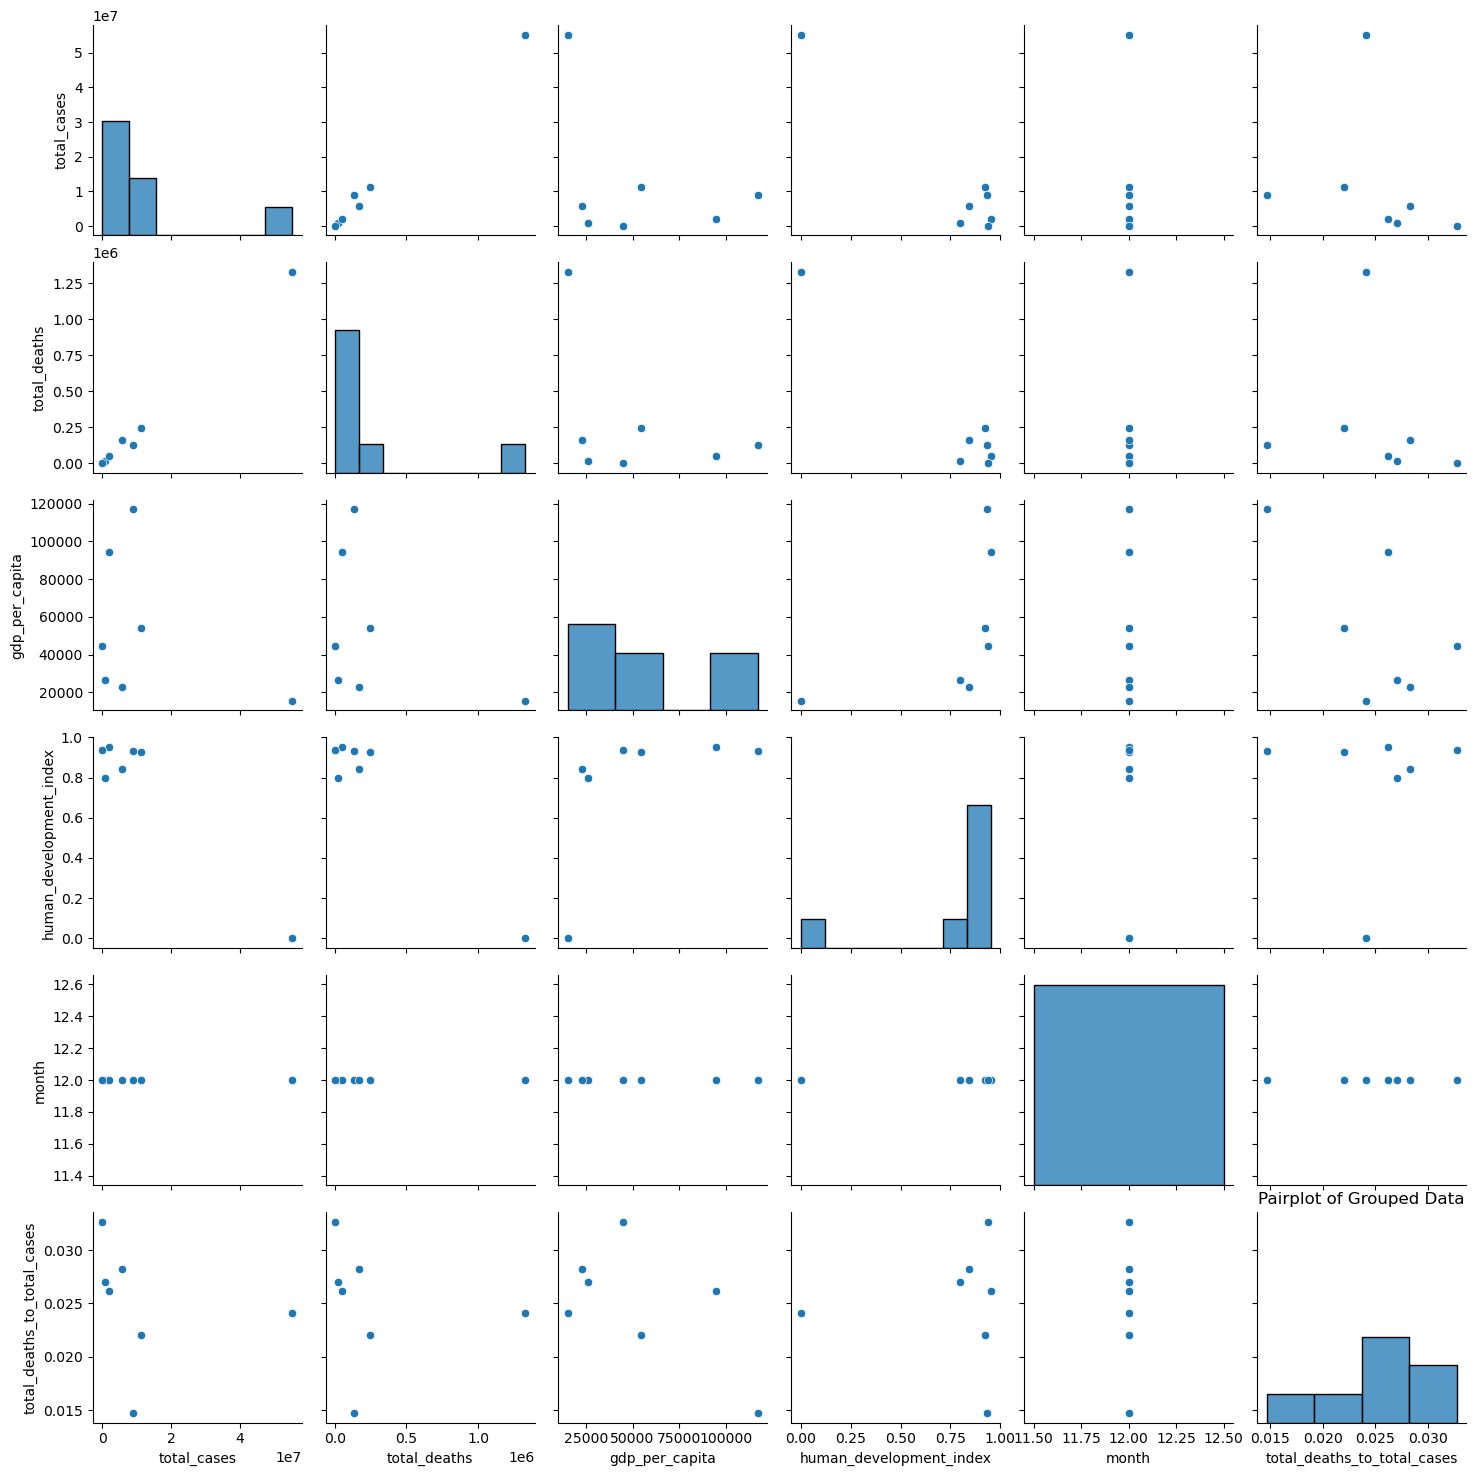

In [90]:
sns.pairplot(df_groupby)
plt.title("Pairplot of Grouped Data")
plt.show()

# d. Plot a bar plot of 'continent' column with 'total_cases' . 

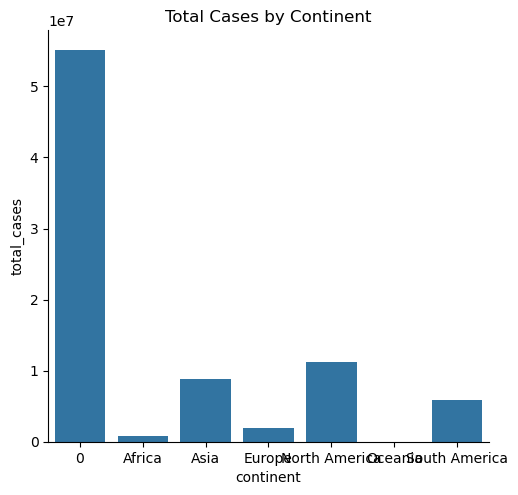

In [91]:
sns.catplot(x="continent", y="total_cases", kind="bar", data=df_groupby)
plt.title("Total Cases by Continent")
plt.show()

# 10.Save the df_groupby dataframe in your local drive using pandas.to_csv function . 

In [92]:
df_groupby.to_csv("Covid_Analysis_Output.csv", index=False)
print("\nAnalysis completed! Data saved as 'Covid_Analysis_Output.csv'.")



Analysis completed! Data saved as 'Covid_Analysis_Output.csv'.
